## Visualize HWiNFO data

This notebook is used to visualize the HWiNFO data collected during the 10-minute test run using Cinebench 2026.

Three configurations were tested:

- Laptop on a flat surface.
- Lifted laptop.
- Laptop on the Flydigi BS2 cooling pad.

We focus on the second configuration in this notebook, and the other two configurations will be visualized in separate notebooks.

### Lifted configuration

Let's start by loading the data.

In [1]:
import pandas as pd


df = pd.read_csv(
    filepath_or_buffer="../data/cinebench_lifted.csv",
    encoding="iso-8859-1",
    low_memory=False,
)

df = df[:-2]
print(f"Shape: {df.shape}")

Shape: (324, 509)


As you can see below, the data has been successfully loaded.

In [2]:
df

,Date,Time,Virtual Memory Committed [MB],Virtual Memory Available [MB],Virtual Memory Load [%],Physical Memory Used [MB],Physical Memory Available [MB],Physical Memory Load [%],Page File Usage [%],Page File Total [MB],...,Total UP [MB],Current DL rate [KB/s],Current UP rate [KB/s],Total DL [MB].1,Total UP [MB].1,Current DL rate [KB/s].1,Current UP rate [KB/s].1,Total Errors [],GPU Core (NVVDD) Input Power (sum) [W],Unnamed: 508
0,18.4.2026,19:59:27.369,16613,28573,36.7,12852,19534,39.6,0.7,12800,...,0,0.0,0.0,3739,90,0.0,0.0,0,0.000,NaN
1,18.4.2026,19:59:29.376,16660,28526,36.8,12882,19504,39.7,0.7,12800,...,0,0.0,0.0,3739,90,0.2,0.1,0,0.000,NaN
2,18.4.2026,19:59:31.381,17953,27233,39.7,13916,18470,42.9,0.7,12800,...,0,0.0,0.0,3739,90,0.0,0.0,0,0.000,NaN
3,18.4.2026,19:59:33.394,19293,25893,42.6,14803,17583,45.7,0.7,12800,...,0,0.0,0.0,3739,90,0.0,0.0,0,0.000,NaN
4,18.4.2026,19:59:35.379,20455,24731,45.2,15897,16489,49.0,0.7,12800,...,0,0.0,0.0,3739,90,0.2,0.1,0,0.000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
319,18.4.2026,20:10:5.585,22379,22807,49.5,17368,15018,53.6,0.8,12800,...,0,0.0,0.0,3739,90,0.1,0.0,0,0.000,NaN
320,18.4.2026,20:10:7.577,22379,22807,49.5,17370,15016,53.6,0.8,12800,...,0,0.0,0.0,3739,90,0.0,0.0,0,0.000,NaN
321,18.4.2026,20:10:9.587,22379,22807,49.5,17372,15014,53.6,0.8,12800,...,0,0.0,0.0,3739,90,0.6,0.7,0,0.000,NaN
322,18.4.2026,20:10:11.581,22390,22796,49.5,17377,15009,53.6,0.8,12800,...,0,0.0,0.0,3739,90,0.0,0.0,0,0.000,NaN


### Select columns of interest

HWiNFO collects a lot of data, but we are only interested in a few columns for our analysis.

In [3]:
useful_columns = [
    "Date",
    "Time",
    "CPU Package [°C]",
    "GPU Temperature [°C]",
    "CPU Package Power [W]",
    "GPU Power [W]",
    "P-core 0 Clock [MHz]",
    "GPU Clock [MHz]",
]

clean_df = df[useful_columns].copy()
clean_df

,Date,Time,CPU Package [°C],GPU Temperature [°C],CPU Package Power [W],GPU Power [W],P-core 0 Clock [MHz],GPU Clock [MHz]
0,18.4.2026,19:59:27.369,52,42.3,5.544,1.392,2493.9,210.0
1,18.4.2026,19:59:29.376,52,42.4,11.185,1.412,2493.9,210.0
2,18.4.2026,19:59:31.381,61,42.5,18.322,2.025,4688.5,210.0
3,18.4.2026,19:59:33.394,71,43.0,55.371,1.510,4389.3,210.0
4,18.4.2026,19:59:35.379,61,43.9,74.169,2.172,2493.9,210.0
...,...,...,...,...,...,...,...,...
319,18.4.2026,20:10:5.585,95,57.3,115.166,1.639,3990.2,210.0
320,18.4.2026,20:10:7.577,95,57.3,114.318,1.627,4090.0,210.0
321,18.4.2026,20:10:9.587,95,57.3,115.133,1.638,4090.0,210.0
322,18.4.2026,20:10:11.581,95,57.3,115.835,1.658,4090.0,210.0


### Compute new columns

Merge the "Date" and "Time" columns into a single "DateTime" column.

In [4]:
clean_df["DateTime"] = clean_df["Date"] + " " + clean_df["Time"]
clean_df["DateTime"] = pd.to_datetime(
    arg=clean_df["DateTime"],
    format="%d.%m.%Y %H:%M:%S.%f",
    errors="coerce",
)

Calculate the "Minutes" column, which represents the time in minutes since the start of the experiment.

In [5]:
start_datetime = clean_df["DateTime"].iloc[0]
time_diff = clean_df["DateTime"] - start_datetime
clean_df["Minutes"] = time_diff.dt.total_seconds() / 60

print(f"Original shape : {df.shape}")
print(f"New shape      : {clean_df.shape}")

Original shape : (324, 509)
New shape      : (324, 10)


### Cast columns to appropriate data types

Let's first see if we have missing values in our cleaned DataFrame.

In [6]:
missing_values = clean_df.isnull().sum().sum()
missing_percentage = (missing_values / clean_df.size) * 100

print(f"Missing values: {missing_values} ({missing_percentage:.2f}%)")

Missing values: 0 (0.00%)


No missing values, that is great! We can now proceed to casting the columns to appropriate data types.

In [7]:
clean_df.head()

,Date,Time,CPU Package [°C],GPU Temperature [°C],CPU Package Power [W],GPU Power [W],P-core 0 Clock [MHz],GPU Clock [MHz],DateTime,Minutes
0,18.4.2026,19:59:27.369,52,42.3,5.544,1.392,2493.9,210.0,2026-04-18 19:59:27.369,0.000000
1,18.4.2026,19:59:29.376,52,42.4,11.185,1.412,2493.9,210.0,2026-04-18 19:59:29.376,0.033450
2,18.4.2026,19:59:31.381,61,42.5,18.322,2.025,4688.5,210.0,2026-04-18 19:59:31.381,0.066867
3,18.4.2026,19:59:33.394,71,43.0,55.371,1.510,4389.3,210.0,2026-04-18 19:59:33.394,0.100417
4,18.4.2026,19:59:35.379,61,43.9,74.169,2.172,2493.9,210.0,2026-04-18 19:59:35.379,0.133500


Observer the current data types of the columns.

In [8]:
clean_df.dtypes

Date                             object
Time                             object
CPU Package [°C]                 object
GPU Temperature [°C]             object
CPU Package Power [W]            object
GPU Power [W]                    object
P-core 0 Clock [MHz]             object
GPU Clock [MHz]                  object
DateTime                 datetime64[ns]
Minutes                         float64
dtype: object

"DateTime" and "Minutes" have correct data types, but the other columns are of type "object", which means they are currently treated as strings.

We will need to convert them to numeric data types for our analysis.

In [9]:
useful_columns

['Date',
 'Time',
 'CPU Package [°C]',
 'GPU Temperature [°C]',
 'CPU Package Power [W]',
 'GPU Power [W]',
 'P-core 0 Clock [MHz]',
 'GPU Clock [MHz]']

Drop the "Date" and "Time" columns and create a new set of numeric columns.

In [10]:
numeric_columns = list(set(useful_columns) - {"Date", "Time"})
print("\n".join(numeric_columns))

GPU Power [W]
GPU Temperature [°C]
GPU Clock [MHz]
P-core 0 Clock [MHz]
CPU Package [°C]
CPU Package Power [W]


In [11]:
for column in numeric_columns:
    clean_df[column] = pd.to_numeric(clean_df[column], errors="coerce")

Let's verify the data types of the columns after conversion.

In [12]:
clean_df.dtypes

Date                             object
Time                             object
CPU Package [°C]                  int64
GPU Temperature [°C]            float64
CPU Package Power [W]           float64
GPU Power [W]                   float64
P-core 0 Clock [MHz]            float64
GPU Clock [MHz]                 float64
DateTime                 datetime64[ns]
Minutes                         float64
dtype: object

### Statistical summary of the data

Let's compute the statistical summary of the numeric columns.

In [13]:
clean_df[list(numeric_columns)].describe()

,GPU Power [W],GPU Temperature [°C],GPU Clock [MHz],P-core 0 Clock [MHz],CPU Package [°C],CPU Package Power [W]
count,324.000000,324.000000,324.0,324.000000,324.000000,324.000000
mean,1.635290,56.412346,210.0,4171.621296,93.518519,113.840346
std,0.135645,2.262899,0.0,239.665805,5.035751,12.865698
min,1.391000,42.300000,210.0,2493.900000,52.000000,5.544000
25%,1.615000,56.600000,210.0,4090.000000,93.000000,114.553000
50%,1.627500,56.900000,210.0,4189.800000,95.000000,115.712000
75%,1.642000,57.100000,210.0,4289.500000,95.000000,116.795750
max,3.340000,58.100000,210.0,4688.500000,97.000000,132.308000


We see that `min` is `0` for some columns. Don't worry about that because at the beginning of recording `HWiNFO` might not have been able to read the values of some sensors, which is why we have `0` values in the data.

### Visualize the data

Configure Jupyter to display plots in `SVG` format for better quality.

In [14]:
%config InlineBackend.figure_format = 'svg'

Let's visualize the CPU package temperature over time.

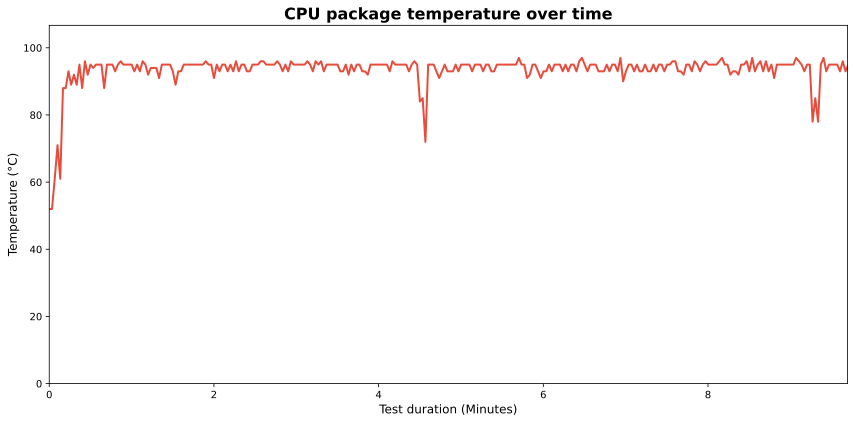

In [15]:
import matplotlib.pyplot as plt

figure_size = (12, 6)
column_to_plot = "CPU Package [°C]"

plt.figure(figsize=figure_size)

plt.plot(
    clean_df["Minutes"],
    clean_df[column_to_plot],
    color="#e74c3c",
    linewidth=2,
)

plt.title(
    label="CPU package temperature over time",
    fontsize=16,
    fontweight="bold",
)

plt.xlabel("Test duration (Minutes)", fontsize=12)
plt.ylabel("Temperature (°C)", fontsize=12)

plt.xlim(0, clean_df["Minutes"].max() * 0.9)
plt.ylim(0, clean_df[column_to_plot].max() * 1.1)

plt.tight_layout()

image_folder = "../images/cinebench_lifted"
plt.savefig(f"{image_folder}/cpu_package_temperature.svg", format="svg")
plt.show()

If you find the data too noisy, you can smooth it using a rolling average.

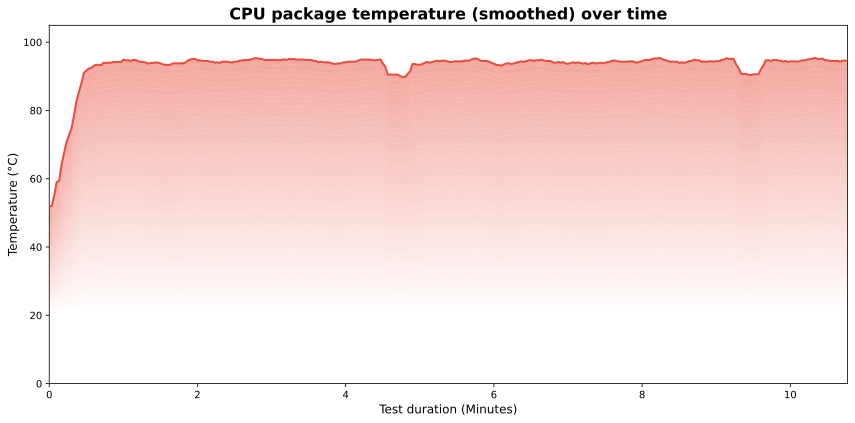

In [16]:
import numpy as np
import matplotlib.pyplot as plt

smoothed_values = clean_df[column_to_plot].rolling(window=10, min_periods=1).mean()
y_values = smoothed_values.to_numpy()
x_values = clean_df["Minutes"].to_numpy()

plt.figure(figsize=figure_size)

plt.plot(
    x_values,
    y_values,
    color="#e74c3c",
    linewidth=2,
    zorder=5,
)

num_steps = 50
y_steps = np.linspace(20, y_values, num_steps)

for i in range(num_steps - 1):
    alpha_level = (i / num_steps) * 0.5
    plt.fill_between(
        x_values,
        y_steps[i],
        y_steps[i + 1],
        color="#e74c3c",
        alpha=alpha_level,
        linewidth=0,
        zorder=2,
    )

plt.title(
    label="CPU package temperature (smoothed) over time",
    fontsize=16,
    fontweight="bold",
)

plt.xlabel("Test duration (Minutes)", fontsize=12)
plt.ylabel("Temperature (°C)", fontsize=12)

plt.xlim(np.nanmin(x_values), np.nanmax(x_values))
plt.ylim(0, np.nanmax(y_values) * 1.1)

plt.tight_layout()

image_folder = "../images/cinebench_lifted"
plt.savefig(f"{image_folder}/cpu_package_temperature_smoothed.svg", format="svg")
plt.show()